# Project: Transformer로 번역기 만들기


---

### Step 0-1. 패키지 설치 · 한글 폰트 설정


In [ ]:
# 필요한 라이브러리 설치 (Colab)
!pip install -q sentencepiece                     # 서브워드 토크나이저
!apt-get -qq -y install fonts-nanum > /dev/null   # 시각화 한글 폰트

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')  # 폰트 등록
plt.rcParams['font.family'] = 'NanumBarunGothic'   # matplotlib 기본 폰트 지정
plt.rcParams['axes.unicode_minus'] = False         # 마이너스 기호 깨짐 방지

print("설치 완료")

설치 완료


### Step 0-2. 라이브러리 임포트 · 시드 고정 · device


In [ ]:
import numpy as np                                    # 수치 계산
import torch                                          # PyTorch 딥러닝 프레임워크
import torch.nn as nn                                 # 신경망 레이어 모듈
import torch.nn.functional as F                       # softmax, cross_entropy 등 함수형 API
from nltk.translate.bleu_score import sentence_bleu   # BLEU 점수 계산
from nltk.translate.bleu_score import SmoothingFunction  # BLEU 0점 방지 스무딩

import re      # 정규표현식 (텍스트 정제)
import os      # 파일 경로/존재 확인
import math    # sqrt 등 수학 함수

from tqdm.notebook import tqdm   # 진행 상황 프로그레스 바

# 재현성을 위한 시드 고정 (매번 같은 결과가 나오도록)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 cuda, 없으면 cpu 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print("Device:", device)

2.11.0+cu128
Device: cuda


---

## Step 1. 데이터 다운로드


### Step 1-1. 데이터 내려받기 (wget · tar)

실행 후 `ls` 출력에 `korean-english-park.train.ko` / `.en`

In [ ]:
!mkdir -p data     # 데이터 폴더 생성
!wget -q -nc https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P data
!tar -xzf data/korean-english-park.train.tar.gz -C data   # -xzf: gzip 해제 + 추출을 한 번에
!ls -l data        # .ko / .en 파일 확인

total 33632
-rw-r--r-- 1  501 staff 11982221 Jul 12  2014 korean-english-park.train.en
-rw-r--r-- 1  501 staff 13730884 Jul 12  2014 korean-english-park.train.ko
-rw-r--r-- 1 root root   8718893 Jul 13 01:59 korean-english-park.train.tar.gz


### Step 1-2. 파일 읽기 · 병렬 쌍 확인


In [ ]:
kor_path = "data/korean-english-park.train.ko"   # 한국어 문장 파일
eng_path = "data/korean-english-park.train.en"   # 영어 문장 파일

# 파일을 줄 단위로 읽어 병렬 쌍 확인
with open(kor_path, "r", encoding="utf-8") as f:
    kor_raw = f.read().splitlines()
with open(eng_path, "r", encoding="utf-8") as f:
    eng_raw = f.read().splitlines()

print("전체 데이터 쌍:", len(kor_raw))
print("한국어 예시:", kor_raw[100])   # 같은 인덱스 = 번역 쌍
print("영어 예시  :", eng_raw[100])

전체 데이터 쌍: 94123
한국어 예시: 제 23차 연례 컴덱스 박람회의 개회사를 한 케이츠는 2년여전 기술 산업의 거품이 붕괴된 이후에 첨단 기술에 대해 부정적인 인식이 있다고 말했다.
영어 예시  : Gates, who opened the 23rd annual Comdex trade show, said there was a negative perception of high tech following the collapse of the tech bubble about two years ago.


> ### [체크포인트] Step 1 완료


---

## Step 2. 데이터 정제


### Step 2-1. 문장 정규화 함수 (preprocess_sentence)


In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()   # 조건 1: 대문자를 소문자로 변환
    # 조건 2: 영문자, 완성형 한글(가-힣), 주요 문장부호(?.!,) 외에는 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)   # 조건 3: 문장부호 양옆에 공백
    sentence = re.sub(r"\s+", " ", sentence)            # 둘 이상의 연속 공백을 하나로
    sentence = sentence.strip()                         # 문자열 양 끝 공백 제거
    return sentence

# 동작 확인: 특수문자는 제거되고 문장부호는 분리되는지 확인
print(preprocess_sentence("So-called \"Hallyu\" fans... 12시 땡!"))

so called hallyu fans . . . 시 땡 !


### Step 2-2. 쌍 단위 중복 제거 (clean_corpus)


In [ ]:
def clean_corpus(kor_lines, eng_lines):
    """한-영 쌍 단위로 중복을 제거한 병렬 코퍼스 반환"""
    assert len(kor_lines) == len(eng_lines)   # 병렬 코퍼스는 문장 수가 같아야 함

    # 쌍을 탭으로 묶어 하나의 문자열로 만든 뒤 set으로 중복 제거
    # (소스/타겟을 따로 제거하면 쌍의 대응 관계가 깨지므로 반드시 묶어서 처리)
    # sorted(): set은 순서가 매번 달라지므로 정렬로 재현성 확보
    cleaned = sorted(set("\t".join([k, e]) for k, e in zip(kor_lines, eng_lines)))
    return cleaned


cleaned_corpus = clean_corpus(kor_raw, eng_raw)
print("중복 제거 후 데이터 쌍:", len(cleaned_corpus))

중복 제거 후 데이터 쌍: 78968


### Step 2-3. 정제 적용 → 한/영 코퍼스 구축


In [ ]:
# 정제 적용해서 한/영 코퍼스 구축
kor_corpus = []   # 정제된 한국어 문장
eng_corpus = []   # 정제된 영어 문장

for pair in tqdm(cleaned_corpus):
    parts = pair.split("\t")            # 탭으로 한국어/영어 분리
    if len(parts) != 2:                 # 형식이 깨진 라인은 건너뜀
        continue
    k = preprocess_sentence(parts[0])   # 한국어 정규화
    e = preprocess_sentence(parts[1])   # 영어 정규화
    if len(k) == 0 or len(e) == 0:      # 정제 후 빈 문장은 쌍째로 제외
        continue
    kor_corpus.append(k)
    eng_corpus.append(e)

print("정제 후 데이터 쌍:", len(kor_corpus))
print("한국어 예시:", kor_corpus[100])
print("영어 예시  :", eng_corpus[100])

  0%|          | 0/78968 [00:00<?, ?it/s]

정제 후 데이터 쌍: 78956
한국어 예시: 당신과 내가 하고자 하는 통신 내용을 정부가 들어야 할 권리를 가질 필요가 있다거나 반드시 가져야 한다는 것이 나와 많은 다른 사람들에게는 분명하게 이해되지가 않습니다 .
영어 예시  : it is not clear to me and to a lot of others , that the government necessarily does have or should have the right to listen in to any private communications that you and i might wish to have .


### Step 2-4. 평가셋 100쌍 분리 (데이터 누수 방지)


In [ ]:
# 성능 측정(Step 7)용 평가 데이터를 미리 분리합니다.
# 토크나이저 학습 전에 분리해야 평가 데이터가 학습에 새어 들어가지 않습니다(데이터 누수 방지).
test_size = 100

test_kor = kor_corpus[-test_size:]    # 마지막 100쌍 → 평가용
test_eng = eng_corpus[-test_size:]
kor_corpus = kor_corpus[:-test_size]  # 나머지 → 학습용
eng_corpus = eng_corpus[:-test_size]

print("학습용:", len(kor_corpus), " / 평가용:", len(test_kor))

학습용: 78856  / 평가용: 100


---

## Step 3. 데이터 토큰화


### Step 3-1. 토크나이저 생성 함수 (generate_tokenizer)


In [ ]:
def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    """SentencePiece 서브워드 토크나이저를 학습해서 반환"""
    file = "./%s_corpus.txt" % lang   # 학습용 임시 코퍼스 파일
    model = "%s_spm" % lang           # 결과 모델 이름 (ko_spm.model / ko_spm.vocab 생성)

    # SentencePiece는 파일에서 학습하므로 코퍼스를 텍스트 파일로 저장
    with open(file, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(str(row) + "\n")

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        "--input=%s --model_prefix=%s --vocab_size=%d "     # 입력 파일 / 모델 이름 / 어휘 크기
        "--pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d"   # 특수 토큰 ID 고정
        % (file, model, vocab_size, pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load("%s.model" % model)   # 학습된 모델 로드
    return tokenizer

### Step 3-2. 토크나이저 학습 · 동작 확인


In [ ]:
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000   # 어휘 크기 (한/영 각 2만)

# 토크나이저 학습 (약 1~2분 소요) — 평가셋을 제외한 학습용 코퍼스로만 학습
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# 타겟(영어)에만 <s>, </s>를 자동으로 붙임
en_tokenizer.set_encode_extra_options("bos:eos")

# 동작 확인
print("한국어:", ko_tokenizer.encode_as_pieces(kor_corpus[100]))
print("영어  :", en_tokenizer.encode_as_pieces(eng_corpus[100]))
print("영어 ID (맨 앞 1=<s>, 맨 뒤 2=</s>):", en_tokenizer.encode_as_ids(eng_corpus[100]))

한국어: ['▁당신', '과', '▁내', '가', '▁', '하고자', '▁하는', '▁통신', '▁내용', '을', '▁정부', '가', '▁들어', '야', '▁할', '▁권리', '를', '▁가질', '▁필요', '가', '▁있다', '거', '나', '▁반', '드시', '▁가져야', '▁한다는', '▁것이', '▁나와', '▁많은', '▁다른', '▁사람들에게', '는', '▁분명', '하게', '▁이해', '되지', '가', '▁않습니다', '▁.']
영어  : ['<s>', '▁it', '▁is', '▁not', '▁clear', '▁to', '▁me', '▁and', '▁to', '▁a', '▁lot', '▁of', '▁others', '▁,', '▁that', '▁the', '▁government', '▁necessar', 'ily', '▁does', '▁have', '▁or', '▁should', '▁have', '▁the', '▁right', '▁to', '▁listen', '▁in', '▁to', '▁any', '▁private', '▁communication', 's', '▁that', '▁you', '▁and', '▁i', '▁might', '▁wish', '▁to', '▁have', '▁.', '</s>']
영어 ID (맨 앞 1=<s>, 맨 뒤 2=</s>): [1, 28, 22, 43, 423, 8, 383, 13, 8, 9, 740, 11, 531, 6, 19, 4, 69, 6762, 2375, 453, 37, 72, 291, 37, 4, 378, 8, 2714, 12, 8, 204, 811, 1625, 7, 19, 105, 13, 55, 578, 3057, 8, 37, 5, 2]


---

## Step 4. 데이터 벡터화


### Step 4-1. 토큰 ID 변환 · 길이 필터링 · 패딩


In [ ]:
def pad_sequences(sequences, padding_value=0):
    """길이가 제각각인 시퀀스들을 가장 긴 길이에 맞춰 0으로 채워 [N, max_len] 텐서로"""
    return torch.nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True,             # 결과 shape을 (문장 수, 최대 길이)로
        padding_value=padding_value)  # 패딩 값 = <pad> 토큰 ID(0)와 일치


MAX_LEN = 50   # 토큰 50개 이하인 문장 쌍만 사용

src_corpus = []   # 한국어 토큰 ID 텐서 목록
tgt_corpus = []   # 영어 토큰 ID 텐서 목록

for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])   # 문장 → ID 리스트
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    # 한쪽만 통과하면 번역 쌍이 깨지므로 둘 다 조건을 만족해야 채택
    if 0 < len(src_tokens) <= MAX_LEN and 0 < len(tgt_tokens) <= MAX_LEN:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))  # 임베딩은 long 타입 요구
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

enc_train = pad_sequences(src_corpus)   # 인코더 입력 (한국어)
dec_train = pad_sequences(tgt_corpus)   # 디코더 입력 (영어, <s>~</s> 포함)

print("enc_train:", enc_train.shape)
print("dec_train:", dec_train.shape)

  0%|          | 0/78856 [00:00<?, ?it/s]

enc_train: torch.Size([72005, 50])
dec_train: torch.Size([72005, 50])


### Step 4-2. DataLoader 구성


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
# 소스 텐서와 타겟 텐서를 묶어 하나의 데이터셋으로 (같은 인덱스 = 번역 쌍)
train_dataset = TensorDataset(enc_train, dec_train)
# shuffle: 매 에폭마다 순서 섞기 / pin_memory: CPU→GPU 전송 속도 향상
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print("배치 수:", len(train_dataloader))

배치 수: 1126


---

## Step 5. 모델 설계


### Step 5-1. Positional Encoding


In [ ]:
# Positional Encoding 구현 ("Attention Is All You Need"의 사인파 방식)
# Transformer는 단어를 동시에 처리하므로 "몇 번째 단어인지" 정보를 벡터로 만들어 더해줌
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        # 위치와 차원 인덱스로 각도 계산: pos / 10000^(2i/d_model)
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        # 한 위치에 대한 d_model개의 각도 벡터
        return [cal_angle(position, i) for i in range(d_model)]

    # 모든 위치 x 모든 차원의 각도 표 생성: [pos, d_model]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])   # 짝수 차원에는 사인
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])   # 홀수 차원에는 코사인

    return sinusoid_table

### Step 5-2. 마스크 생성 (패딩 · 룩어헤드)


In [ ]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """(seq == 0)인 위치가 1인 [batch, 1, 1, seq_len] 패딩 마스크
    → 의미 없는 <pad> 위치를 어텐션이 무시하도록 함"""
    # unsqueeze 2번: 멀티헤드 어텐션 점수 [batch, heads, len, len]와 브로드캐스팅 되도록 차원 확장
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """미래 토큰(대각선 위)이 1인 [size, size] 룩어헤드 마스크
    → 디코더가 자기 이전 단어만 보도록 미래를 차단 (컨닝 방지)"""
    # triu(diagonal=1): 주대각선 위쪽만 1인 상삼각 행렬
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    # 1) 인코더 자기어텐션용: 소스의 패딩만 가림
    enc_mask = generate_padding_mask(src)
    # 2) 디코더-인코더(크로스) 어텐션용: 역시 소스의 패딩을 가림
    #    (인코더 출력은 "미래"가 아니므로 causality 제한은 불필요.
    #     한-영처럼 어순이 다른 언어 쌍에서는 오히려 해로움)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션용: 룩어헤드 + 타겟 패딩 마스크를 합침
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])   # [tgt_len, tgt_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)            # [batch, 1, 1, tgt_len]

    # 배치/헤드 차원과 맞도록 확장: [1, 1, tgt_len, tgt_len]
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    # max로 병합: 둘 중 하나라도 1이면 1 → "패딩이거나 미래인 위치"를 모두 가림
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

### Step 5-3. Multi-Head Attention


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads   # 각 헤드가 담당할 차원 수 (512/8=64)

        # Query, Key, Value를 만드는 선형 변환
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        # 헤드들의 출력을 결합한 뒤 통과시키는 최종 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))   # 모든 단어 쌍의 유사도 점수 [.., len, len]

        # sqrt(d_k)로 나눠 스케일링 (softmax가 극단적으로 치우치는 것 방지)
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            # 마스크가 1인 위치(패딩/미래)에 -10억을 더해 softmax 후 확률이 0에 수렴하게 함
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)   # 유사도를 확률로 변환
        out = torch.matmul(attentions, V)           # 확률 비율대로 V를 가중합

        return out, attentions

    def split_heads(self, x):
        # [batch, len, d_model] → [batch, heads, len, depth]로 재배치
        # d_model 벡터를 heads개 조각으로 나눠 각 헤드가 독립적으로 어텐션하게 함
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        # split_heads의 역연산: [batch, heads, len, depth] → [batch, len, d_model]
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # 1) 선형 변환으로 Q, K, V 생성
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 2) 멀티헤드로 분할
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 3) 각 헤드에서 독립적으로 어텐션 수행
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # 4) 헤드 결합 후 최종 선형 변환
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

### Step 5-4. Position-wise Feed Forward Network


In [ ]:
class PoswiseFeedForwardNet(nn.Module):
    """위치별 피드포워드: 어텐션으로 모인 정보를 각 단어 위치에서 개별 가공
    구조: d_model → d_ff(확장) → ReLU → d_model(압축)"""
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)   # 차원 확장 (512 → 2048)
        self.fc2 = nn.Linear(d_ff, d_model)   # 다시 원래 차원으로 압축
        self.relu = nn.ReLU()                 # 비선형성 추가

    def forward(self, x):
        out = self.relu(self.fc1(x))   # 확장 + 활성화
        out = self.fc2(out)            # 압축
        return out

### Step 5-5. Encoder Layer


In [ ]:
class EncoderLayer(nn.Module):
    """인코더 레이어 = 자기어텐션 블록 + FFN 블록
    각 블록: LayerNorm → 연산 → Dropout → 잔차 연결 (Pre-LN 방식)"""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)   # 자기어텐션
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)             # 피드포워드

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)   # 어텐션 앞 정규화
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)   # FFN 앞 정규화

        self.do = nn.Dropout(dropout)   # 과적합 방지

    def forward(self, x, mask):
        # --- 자기어텐션 블록 ---
        residual = x                # 잔차 연결용 입력 보관
        out = self.norm_1(x)
        # Q=K=V 모두 같은 입력 → "자기"어텐션 (문장 내 단어끼리 문맥 교환)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual        # 잔차 연결: 기울기 흐름 안정화

        # --- FFN 블록 ---
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, enc_attn

### Step 5-6. Decoder Layer


In [ ]:
class DecoderLayer(nn.Module):
    """디코더 레이어 = 마스크드 자기어텐션 + 크로스 어텐션 + FFN (블록 3개)"""
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 마스크드 자기어텐션
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)    # 인코더-디코더 크로스 어텐션
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # --- 1. 마스크드 자기어텐션: 생성 중인 번역끼리, 미래 토큰은 차단 ---
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # --- 2. 크로스 어텐션: Q는 디코더, K/V는 인코더 출력 ---
        # "지금 생성하려는 영어 단어가 한국어 원문의 어느 단어를 참고해야 하는가"
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # --- 3. FFN ---
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

### Step 5-7. Encoder 스택 (+ final LayerNorm)


In [ ]:
class Encoder(nn.Module):
    """EncoderLayer를 n_layers개 쌓은 인코더 전체"""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # ModuleList: 파라미터가 모델에 등록되도록 (일반 리스트면 학습에서 누락됨)
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 스택 마지막 출력 정규화용 LayerNorm
        # (없으면 잔차 누적으로 출력 norm이 커져 어텐션 포화/모드 붕괴 위험)
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = x
        enc_attns = []                     # 시각화용 어텐션 가중치 수집
        for i in range(self.n_layers):     # 레이어를 차례차례 통과
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        out = self.final_norm(out)   # 스택 끝나고 정규화 (Pre-LN 표준)
        return out, enc_attns

### Step 5-8. Decoder 스택 (+ final LayerNorm)


In [ ]:
class Decoder(nn.Module):
    """DecoderLayer를 n_layers개 쌓은 디코더 전체"""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 스택 마지막 출력 정규화용 LayerNorm
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            # 모든 레이어가 같은 인코더 출력(enc_out)을 참조
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)   # 스택 끝나고 정규화 (Pre-LN 표준)
        return out, dec_attns, dec_enc_attns

### Step 5-9. Transformer 전체 모델


In [ ]:
class Transformer(nn.Module):
    """임베딩 + 위치 인코딩 + 인코더 + 디코더 + 출력층을 조립한 최상위 모델"""
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)   # 임베딩 스케일링에 사용

        # 임베딩: 토큰 ID → d_model 차원 벡터
        if shared_emb:
            # 소스/타겟이 같은 언어일 때 임베딩 공유 (한-영 번역은 다른 언어이므로 False)
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)   # 한국어 임베딩
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)   # 영어 임베딩

        # 위치 인코딩: 고정값이므로 파라미터가 아닌 buffer로 등록
        # (학습되지 않지만 model.to(device) 시 함께 이동)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 출력층: 디코더 출력 → 어휘 크기의 점수(logits)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # weight tying: 출력층과 디코더 임베딩의 가중치 공유 (파라미터 절약 + 성능 향상)
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)   # [batch, seq_len, d_model]
        if self.shared_fc:
            # 원논문의 임베딩 스케일링: 위치 인코딩과 값 크기 균형 맞추기
            out = out * math.sqrt(self.d_model)
        # 위치 인코딩을 문장 길이만큼 잘라서 더함
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        # 1) 임베딩 + 위치 인코딩
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # 2) 인코더가 원문을 문맥 표현으로 변환 → 디코더가 참조하며 번역 표현 생성
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        # 3) 각 위치에서 "다음 토큰" 예측 점수 계산: [batch, tgt_len, vocab]
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

---

## Step 6. 훈련하기


### Step 6-1. 하이퍼파라미터 · 모델 생성


In [ ]:
# 하이퍼파라미터 (제출용)
N_LAYERS = 2     # 인코더/디코더 층 수 (논문은 6층, 실습용으로 축소)
D_MODEL = 512    # 모델 전체 벡터 차원 (512 = 8헤드 x 64차원)
N_HEADS = 8      # 어텐션 헤드 수
D_FF = 2048      # FFN 중간 차원 (d_model의 4배)
DROPOUT = 0.2    # 드롭아웃 비율

transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,          # 위치 인코딩 최대 길이 (MAX_LEN=50보다 여유 있게)
    dropout=DROPOUT,
    shared_fc=True,       # 출력층-디코더 임베딩 가중치 공유
    shared_emb=False)     # 한국어/영어는 다른 언어이므로 임베딩은 따로

transformer = transformer.to(device)   # 모델을 GPU로 이동

# 전체 파라미터 수 확인 (공유된 가중치는 한 번만 계산됨)
n_params = sum(p.numel() for p in transformer.parameters())
print("파라미터 수: %.1fM" % (n_params / 1e6))

파라미터 수: 35.2M


### Step 6-2. Noam 학습률 스케줄러 · Adam 옵티마이저


In [ ]:
class LearningRateScheduler:
    """원논문의 Noam 스케줄러: warmup 동안 선형 증가 → 이후 1/sqrt(step)로 감소"""
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5                          # 감쇠 구간 (step > warmup일 때 선택됨)
        arg2 = step * (self.warmup_steps ** -1.5)    # 워밍업 구간 (step < warmup일 때 선택됨)
        # d_model이 클수록 전체 학습률을 낮추는 보정
        return (self.d_model ** -0.5) * min(arg1, arg2)


WARMUP_STEPS = 4000   # 학습 초반 4000스텝 동안 학습률을 서서히 올림 (발산 방지)
learning_rate = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)

# Adam 옵티마이저 (betas, eps는 Transformer 원논문 설정)
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),    # 초기값 (매 스텝 갱신됨)
                             betas=(0.9, 0.98),
                             eps=1e-9)

### Step 6-3. 손실 함수 (패딩 제외 CrossEntropy)


In [ ]:
def loss_function(real, pred):
    """real: [batch, seq_len] / pred: [batch, seq_len, vocab] — 패딩(0) 위치는 손실에서 제외"""
    real = real.to(device)
    pred = pred.to(device)

    # [N, C] 형태로 펼쳐서 토큰별 개별 손실 계산 (reduction='none')
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)),
                            real.contiguous().view(-1), reduction="none")
    loss_ = loss_.view(real.size())   # 다시 [batch, seq_len]로 복원

    # 실제 토큰 위치만 1인 마스크 (패딩=0 위치의 손실을 무효화)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 손실 합 / 실제 토큰 수 = 토큰당 평균 손실 (패딩 비율에 왜곡되지 않음)
    return loss_.sum() / mask.sum()

### Step 6-4. 학습 스텝 (teacher forcing)


In [ ]:
def train_step(src, tgt, model, optimizer):
    model.train()           # 학습 모드 (dropout 활성화)
    optimizer.zero_grad()   # 이전 스텝의 기울기 초기화

    # 타겟 시프트 (teacher forcing):
    # 입력: <s> A B C  /  정답: A B C </s>  → 각 위치에서 "다음 토큰" 맞히기
    tgt_in = tgt[:, :-1]   # 디코더 입력 (마지막 토큰 제외)
    gold = tgt[:, 1:]      # 정답 (첫 토큰 제외)

    # 배치별 마스크 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    # 데이터와 마스크를 GPU로 이동
    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # forward: 예측 logits 계산
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # 패딩 제외 손실 계산
    loss = loss_function(gold, predictions)

    loss.backward()    # 역전파로 기울기 계산
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 기울기 폭주 방지
    optimizer.step()   # 파라미터 갱신

    return loss, enc_attns, dec_attns, dec_enc_attns

### Step 6-5. 학습 실행


In [ ]:
%%time

EPOCHS = 15   # 전체 데이터 반복 학습 횟수 (T4 기준 epoch당 약 2~3분)

global_step = 0      # 학습률 스케줄용 전체 스텝 카운터
loss_history = []    # 손실 그래프용 기록

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # 매 스텝 학습률 스케줄 적용 (warmup 4000 + 감쇠)
        global_step += 1
        lr = learning_rate(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        # 배치 하나 학습
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()          # .item(): 텐서에서 숫자만 추출 (메모리 누적 방지)
        loss_history.append(loss.item())
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}", "LR": f"{lr:.6f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    # 에폭 평균 손실 출력 (꾸준히 감소하면 정상 학습 중)
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

  0%|          | 0/1126 [00:00<?, ?it/s]

Epoch 1, Loss: 117.6705


  0%|          | 0/1126 [00:00<?, ?it/s]

Epoch 2, Loss: 12.2556


  0%|          | 0/1126 [00:00<?, ?it/s]

...

Epoch 13, Loss: 4.9548


  0%|          | 0/1126 [00:00<?, ?it/s]

Epoch 14, Loss: 4.9017


  0%|          | 0/1126 [00:00<?, ?it/s]

Epoch 15, Loss: 4.8506
CPU times: user 50min 6s, sys: 9.45 s, total: 50min 15s
Wall time: 51min 2s


### Step 6-6. 학습 손실 곡선


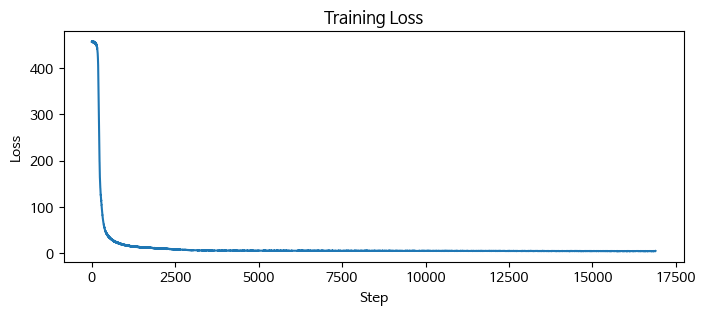

In [ ]:
# 학습 손실 곡선 시각화 (감소 추세 확인)
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

### Step 6-7. 번역 생성 함수 (greedy decoding)


In [ ]:
@torch.no_grad()   # 추론이므로 기울기 계산 생략 (속도/메모리 절약)
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=MAX_LEN):
    model.eval()   # 추론 모드 (dropout 비활성화)

    # 질문을 학습 때와 동일하게 전처리 + 토큰화 + ID 변환
    processed = preprocess_sentence(sentence)
    pieces = src_tokenizer.encode_as_pieces(processed)   # 서브워드 조각 (시각화 라벨용)
    tokens = src_tokenizer.encode_as_ids(processed)      # 토큰 ID (모델 입력용)

    src = torch.tensor([tokens], dtype=torch.long, device=device)               # 인코더 입력 [1, len]
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long, device=device)  # 디코더 첫 입력: <s>

    result_ids = []
    # 자기회귀 생성: 한 번에 한 토큰씩 예측해서 이어 붙임
    for _ in range(max_len):
        # 현재까지의 출력으로 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)

        predictions, enc_attns, dec_attns, dec_enc_attns = model(
            src, output,
            enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))

        # 마지막 위치의 예측에서 확률 최대 토큰 선택 (greedy decoding)
        predicted_id = predictions[0, -1].argmax(dim=-1).item()

        if predicted_id == tgt_tokenizer.eos_id():   # </s>가 나오면 생성 종료
            break

        result_ids.append(predicted_id)
        # 예측한 토큰을 디코더 입력에 이어 붙여 다음 반복에 사용
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    result = tgt_tokenizer.decode_ids(result_ids)   # 토큰 ID → 영어 문장 복원
    # 시각화 라벨은 어텐션 행렬 크기와 일치하는 서브워드 조각으로
    tgt_pieces = ["<s>"] + [tgt_tokenizer.id_to_piece(i) for i in result_ids]

    return pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns

### Step 6-8. Attention Map 시각화 함수


In [ ]:
def visualize_attention(src_labels, tgt_labels, enc_attns, dec_attns, dec_enc_attns,
                        n_heads_show=4):
    """어텐션 가중치를 히트맵으로 시각화 (밝을수록 강한 주목)
    행 = 주목하는 쪽(Query), 열 = 주목받는 쪽(Key)"""
    import seaborn

    # SentencePiece의 단어 시작 표시는 폰트에 없는 경우가 많아 '_'로 치환
    src_labels = [str(l).replace(chr(9601), "_") for l in src_labels]
    tgt_labels = [str(l).replace(chr(9601), "_") for l in tgt_labels]

    def draw(data, ax, x, y):
        seaborn.heatmap(data.detach().cpu().numpy(),   # GPU 텐서 → numpy 변환
                        square=True,
                        vmin=0.0, vmax=1.0,   # 색 범위 고정 (그림 간 비교 가능)
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)
        ax.tick_params(labelsize=8)

    # --- 인코더 자기어텐션: 한국어 문장 내부의 참조 관계 ---
    for layer in range(len(enc_attns)):
        print("Encoder Layer", layer + 1)
        fig, axs = plt.subplots(1, n_heads_show, figsize=(20, 10))
        for h in range(n_heads_show):
            n = min(len(src_labels), enc_attns[layer].shape[-1])
            draw(enc_attns[layer][0, h, :n, :n], axs[h], src_labels[:n], src_labels[:n])
        plt.tight_layout()
        plt.show()

    for layer in range(len(dec_attns)):
        # --- 디코더 자기어텐션: 미래 차단 때문에 하삼각(과거만 참조) 패턴이 정상 ---
        print("Decoder Self Layer", layer + 1)
        L = min(len(tgt_labels), dec_attns[layer].shape[-1])
        fig, axs = plt.subplots(1, n_heads_show, figsize=(20, 10))
        for h in range(n_heads_show):
            draw(dec_attns[layer][0, h, :L, :L], axs[h], tgt_labels[:L], tgt_labels[:L])
        plt.tight_layout()
        plt.show()

        # --- 크로스 어텐션: 행 = 영어 토큰, 열 = 한국어 토큰 ---
        # "이 영어 단어가 한국어 어느 단어를 번역했는지" 정렬 관계가 보임
        print("Decoder Src Layer", layer + 1)
        S = min(len(src_labels), dec_enc_attns[layer].shape[-1])
        fig, axs = plt.subplots(1, n_heads_show, figsize=(20, 10))
        for h in range(n_heads_show):
            draw(dec_enc_attns[layer][0, h, :L, :S], axs[h], src_labels[:S], tgt_labels[:L])
        plt.tight_layout()
        plt.show()

### Step 6-9. translate 함수 (최종 인터페이스)


In [ ]:
# 번역 생성 및 Attention 시각화 결합
def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)   # ← 6개 언패킹

    print('Input: %s' % sentence)
    print('Predicted translation: %s' % result)

    if plot_attention:
        visualize_attention(pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns)

    return result

### Step 6-10. 예문 번역 (제출용)


In [ ]:
# 예문에 대한 번역 생성 (제출용)
example_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

for i, s in enumerate(example_sentences, 1):
    print(f"{i}.", end=" ")
    translate(s, transformer, ko_tokenizer, en_tokenizer)
    print()

1. Input: 오바마는 대통령이다.
Predicted translation: obama is the president of the president s presidential election .

2. Input: 시민들은 도시 속에 산다.
Predicted translation: the ap s s s .

3. Input: 커피는 필요 없다.
Predicted translation: it is a lot of the economy .

4. Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the death toll in the city of the city of the city of the city of the southern city of the southern city of the southern city of the crash crash .



### Step 6-11. Attention Map 확인 (번역 근거)


Input: 오바마는 대통령이다.
Predicted translation: obama is the president of the president s presidential election .
Encoder Layer 1


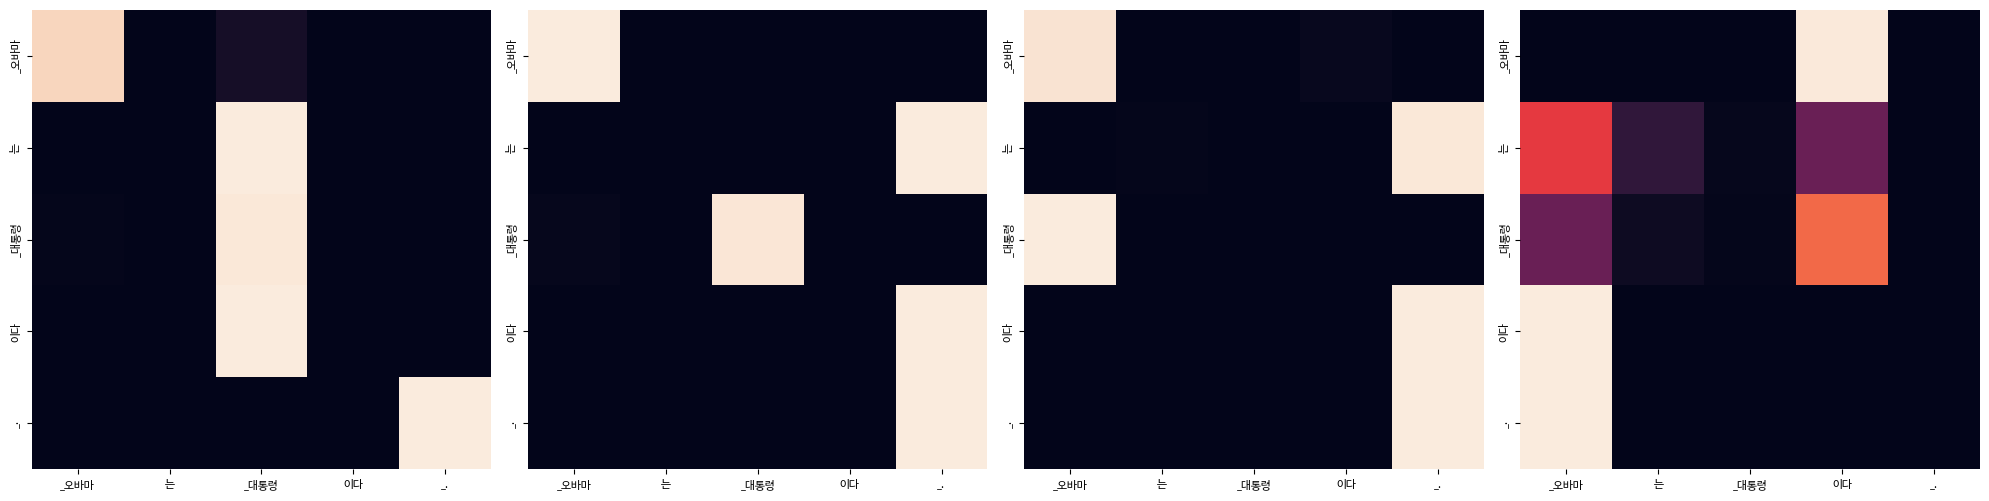

Encoder Layer 2


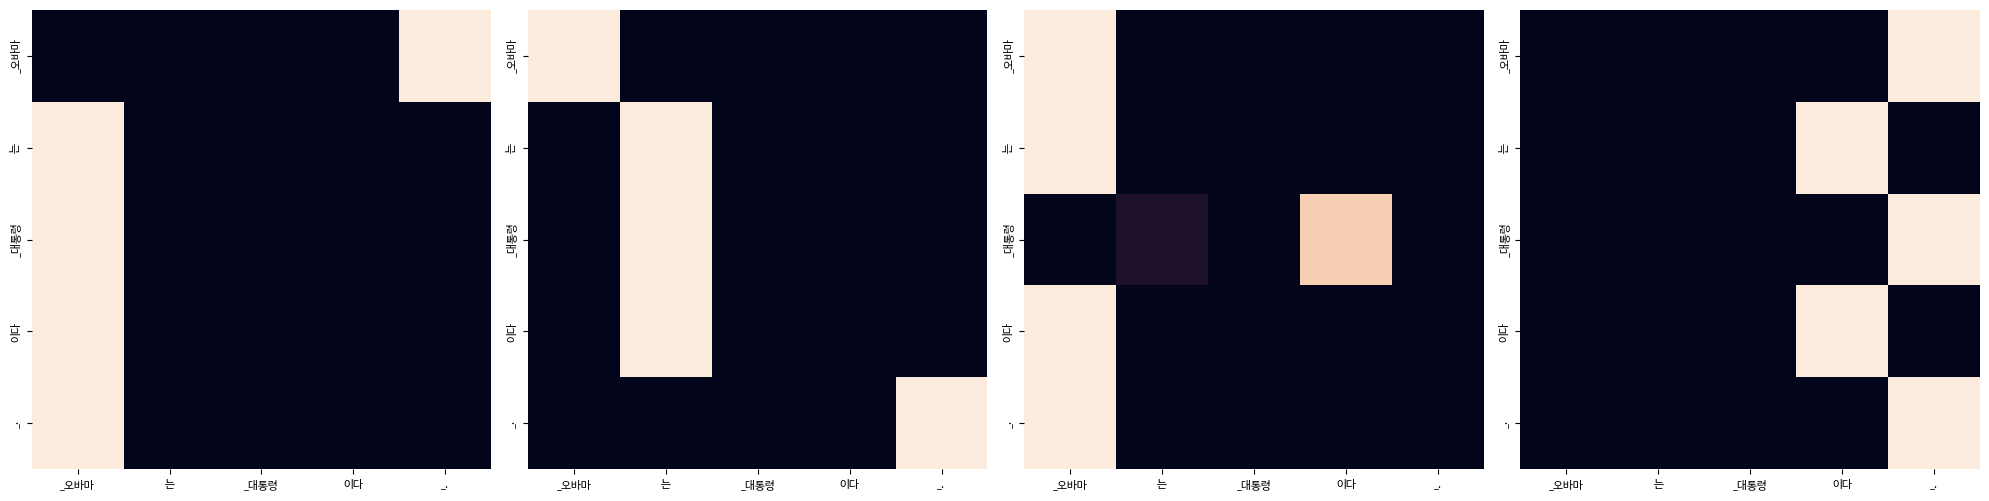

Decoder Self Layer 1


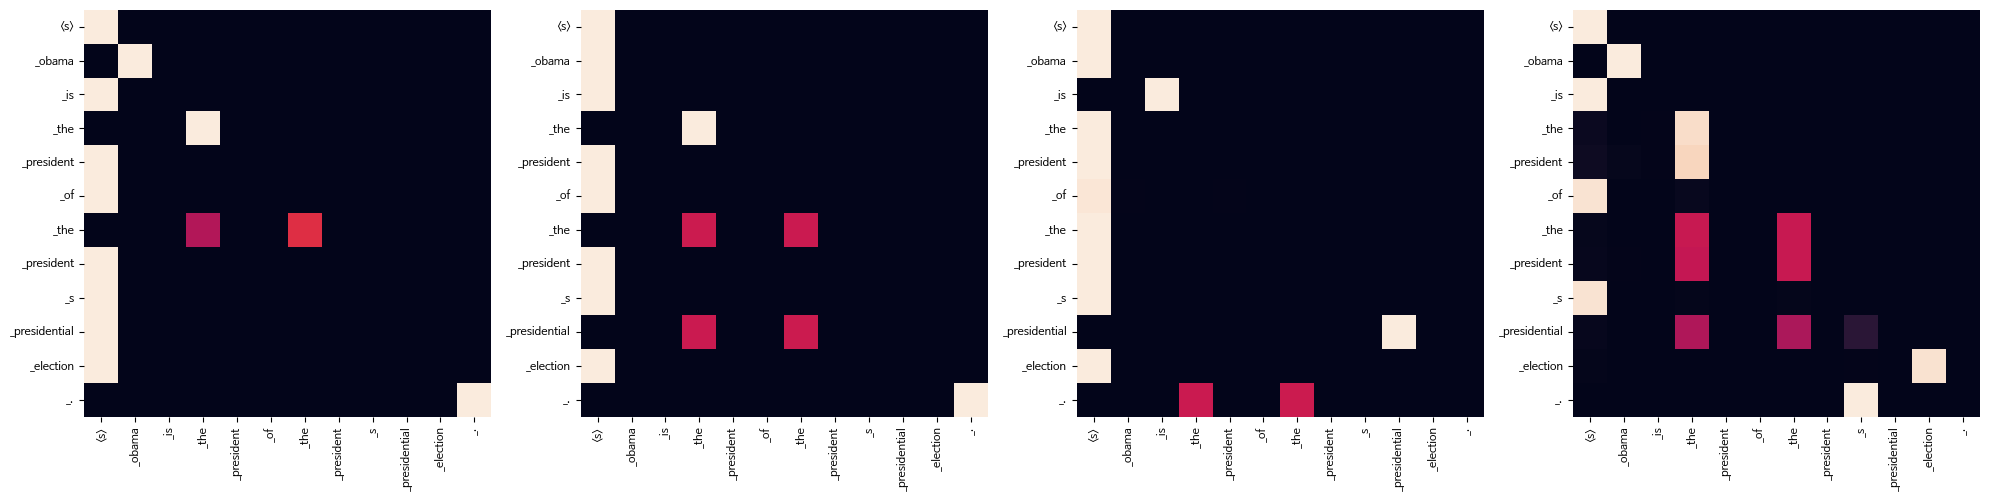

Decoder Src Layer 1


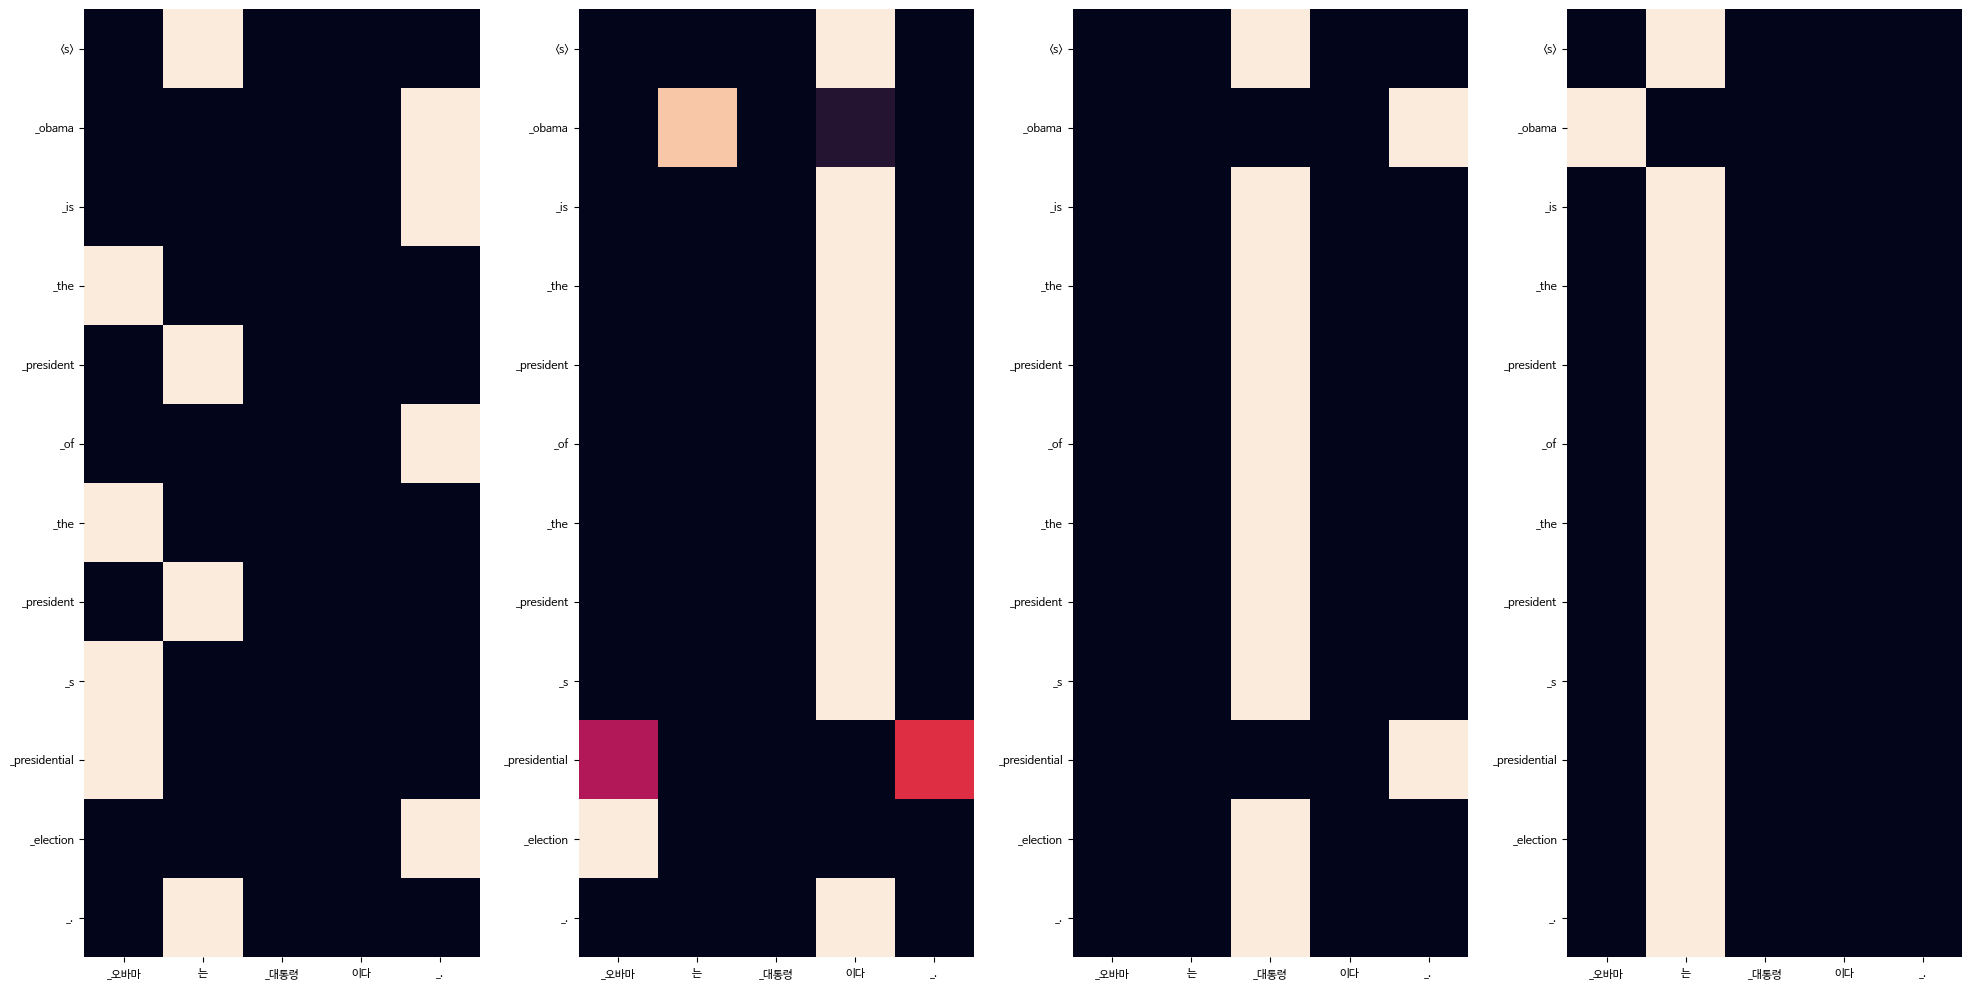

Decoder Self Layer 2


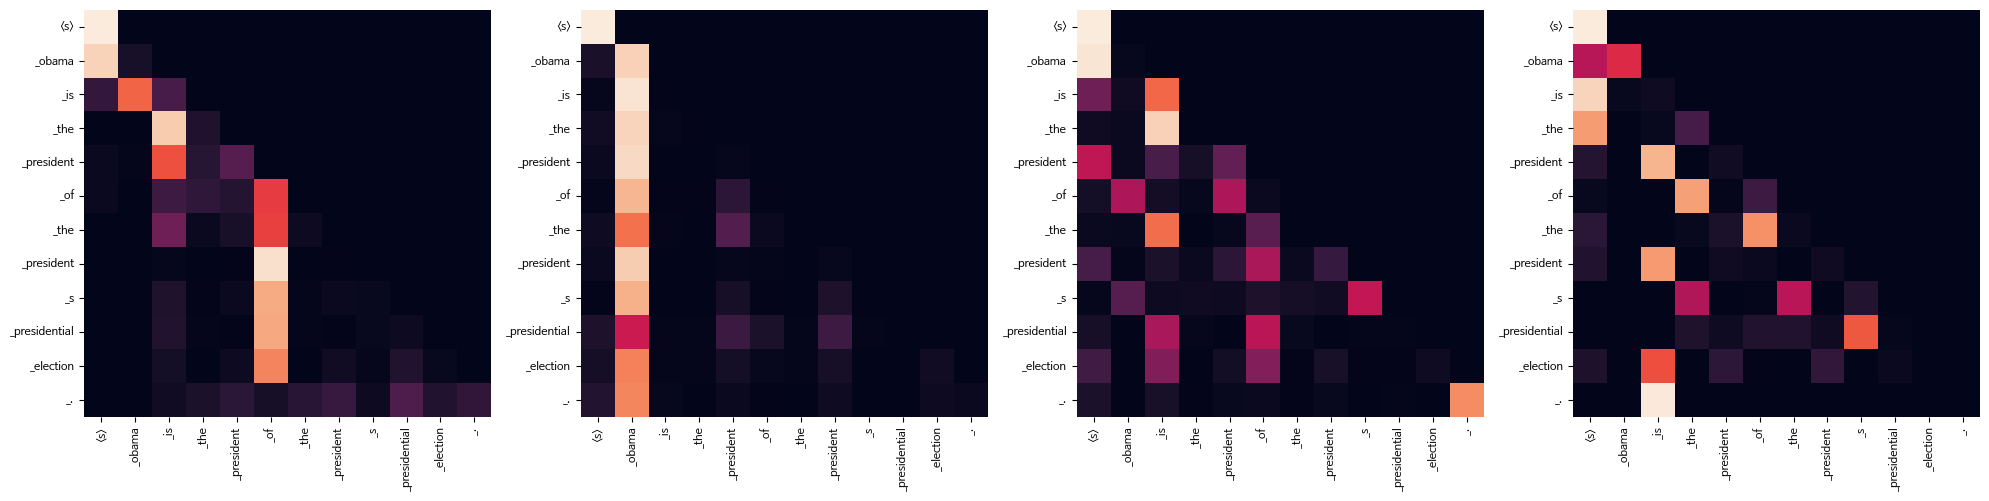

Decoder Src Layer 2


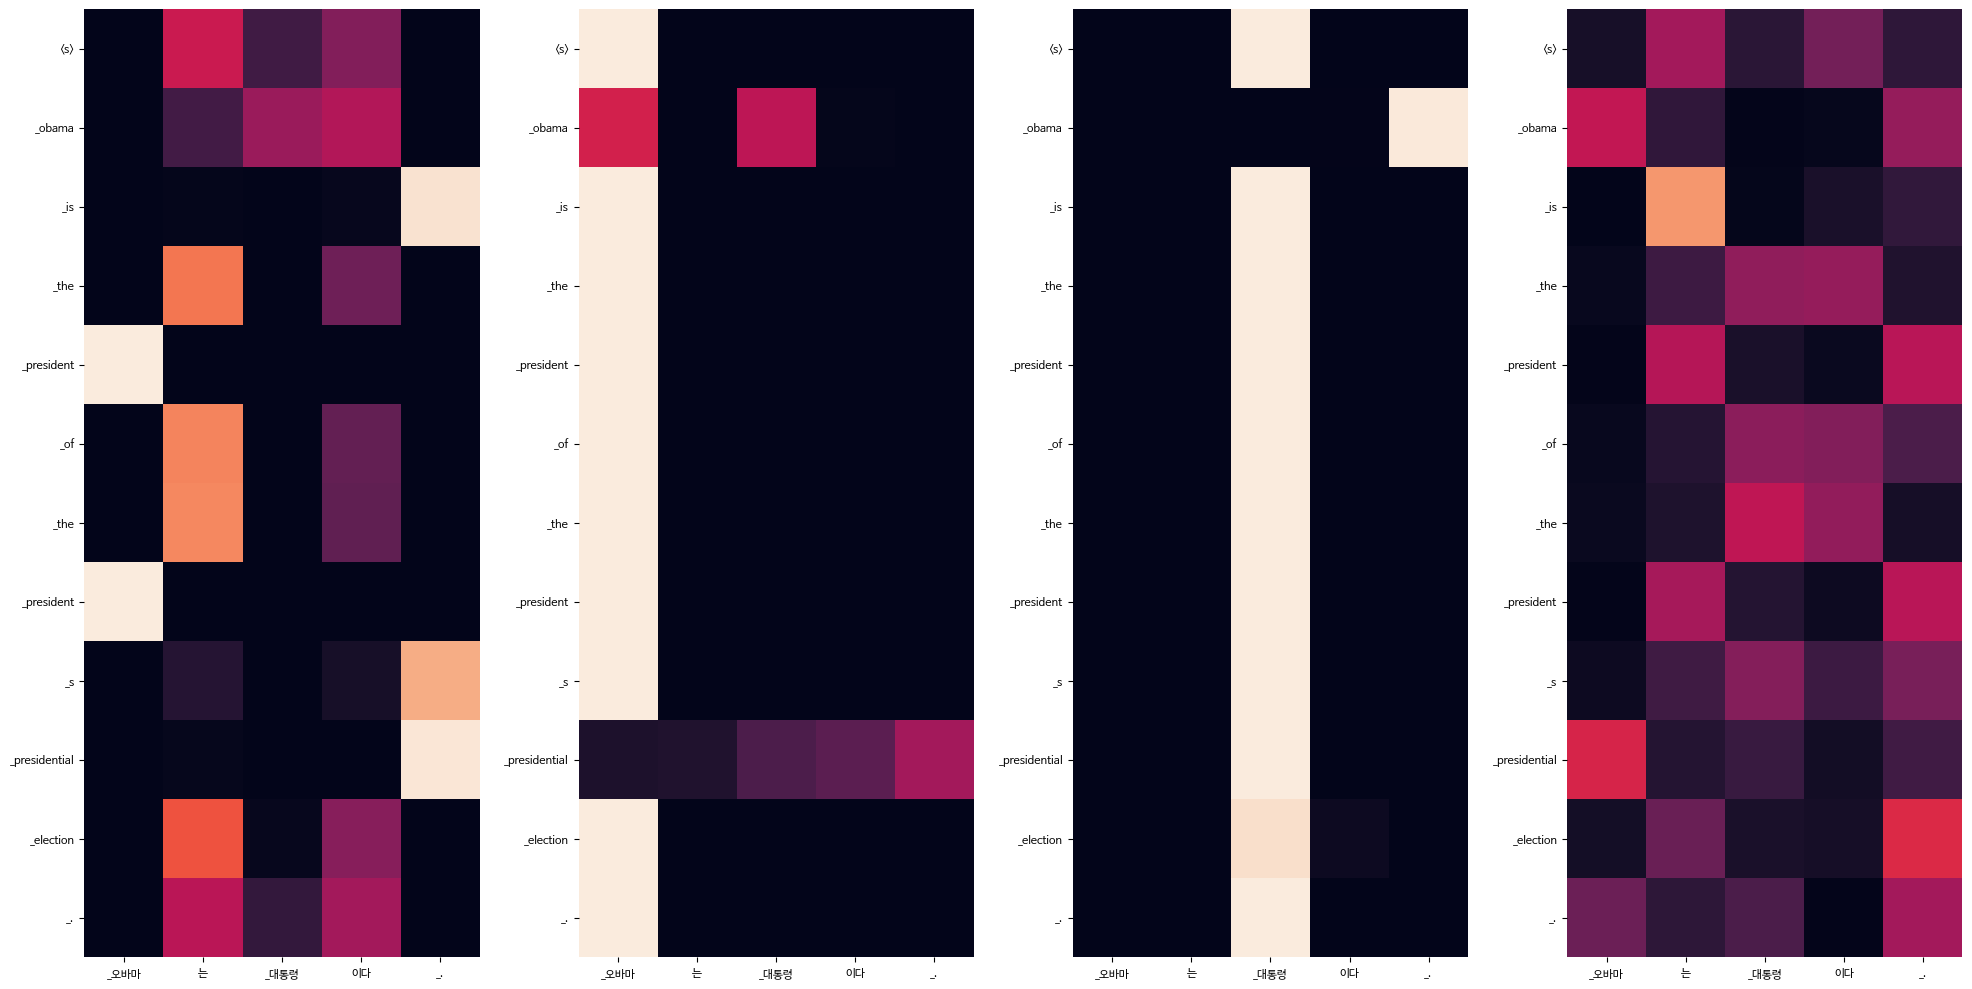

'obama is the president of the president s presidential election .'

In [ ]:
# Attention Map 시각화 (번역 근거 확인)
# Decoder Src Layer 히트맵에서 영어 단어(행)가 어떤 한국어 단어(열)를
# 참조해 번역됐는지 밝은 셀로 확인할 수 있습니다.
translate(example_sentences[0], transformer, ko_tokenizer, en_tokenizer, plot_attention=True)

---

## Step 7. 성능 측정하기


### Step 7-1. BLEU 계산 · 평가셋 번역


In [ ]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    # smoothing_function: n-gram 매칭이 0이어도 점수가 0으로 무너지지 않게 보정
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)


total_score = 0.0
results = []   # (원문, 모델 번역, 정답 번역, 점수) 기록

for kor_sent, eng_sent in tqdm(list(zip(test_kor, test_eng))):
    # 조용히 번역만 생성 (evaluate의 세 번째 반환값이 번역 문자열)
    candidate = evaluate(kor_sent, transformer, ko_tokenizer, en_tokenizer)[2].split()
    reference = eng_sent.split()   # 정답 영어 문장을 공백 단위 토큰으로

    score = calculate_bleu(reference, candidate)
    total_score += score
    results.append((kor_sent, candidate, reference, score))

print("평가 데이터 수:", len(results))
print("Average BLEU: %.4f" % (total_score / len(results)))

  0%|          | 0/100 [00:00<?, ?it/s]

평가 데이터 수: 100
Average BLEU: 0.0112


### Step 7-2. 평가 샘플 확인


In [ ]:
# 평가 샘플 확인 (모델 번역 vs 정답 번역)
for kor_sent, candidate, reference, score in results[:5]:
    print("원문     :", kor_sent)
    print("모델 번역:", " ".join(candidate))
    print("정답 번역:", " ".join(reference))
    print("BLEU: %.4f" % score)
    print()

원문     : 힐러리 클린턴은 미국 대통령 선거에 있어 자신이 공화당 매케인 후보에 대한 최선의 후보라고 말했다 .
모델 번역: mccain said the democratic presidential candidates are expected to between the democratic presidential election .
정답 번역: hillary clinton says she is the best placed candidate for the democrats to beat republican john mccain when it comes to the us presidential elections .
BLEU: 0.0099

원문     : 힐러리 클린턴은 여성 유권자층으로부터 의 지지를 얻어 의 매케인을 큰 격차로 앞섰다 .
모델 번역: clinton s campaign , who has been a new york senator to win the democratic presidential candidates .
정답 번역: sen . hillary clinton , meanwhile , leads mccain among women , percent to percent .
BLEU: 0.0153

원문     : 힐러리 클린턴은 지난 년 월 이후 상원의원에 재임 중이다 .
모델 번역: the new york times reports the first time in january , the first time in january , the first time in january .
정답 번역: hillary clinton has been in the senate since january .
BLEU: 0.0208

원문     : 힐러리 클린턴의 가장 열렬한 지지자 중 명인 톰 빌삭 전 아이오와 주지사가 일 현지시간 클린턴이 이제 패배를 인정해야 할 시간이 왔다고 밝혔다 .
모델 번역: the republican presidential candid

---

## 회고

### 프로젝트 요약

한영 뉴스 병렬 코퍼스 약 9만 쌍으로 Transformer 번역 모델을 밑바닥부터 구현해 학습했다. SentencePiece 서브워드 토크나이저(vocab 각 2만), 2층 인코더/디코더(d_model 512)를 사용했고, 번역 결과를 Attention Map으로 시각화해 모델이 어떤 근거로 번역했는지 확인했다.

### 좋았던 점

- 논문 "Attention Is All You Need"의 구성 요소(위치 인코딩, 멀티헤드 어텐션, 마스크, Noam 스케줄, weight tying)를 하나씩 코드로 옮기며 각 부품이 왜 필요한지 이해했다.
- 크로스 어텐션 히트맵에서 영어 단어가 대응되는 한국어 단어를 실제로 참조하는 것을 눈으로 확인했다. 어순이 다른 두 언어의 정렬(alignment)을 모델이 스스로 학습한다는 점이 인상적이었다.
- 평가 데이터 100쌍을 토크나이저 학습 전에 분리해 데이터 누수를 막는 습관을 적용했다.

### 어려웠던 점과 해결 과정

- **마스크 규약 불일치**: 마스크 생성부는 "1=차단"인데 어텐션 구현이 `masked_fill(mask == 0, ...)`로 0인 위치를 차단해, 실제 토큰이 가려지고 패딩만 참조하는 정반대 동작이었다. 규약을 "1=차단, 점수에 `mask * -1e9` 더하기"로 통일해 해결했다. 에러 없이 조용히 성능만 망가지는 종류의 버그라 찾기 어려웠다.
- positional encoding이 numpy 배열인 채로 torch 메서드(`unsqueeze`, `to`)를 호출해 런타임 에러가 났다. 텐서로 변환해 `register_buffer`로 등록하니 `model.to(device)` 시 자동으로 함께 이동해 깔끔해졌다.
- 크로스 어텐션에 불필요한 causality 마스크가 걸려 있었다. 인코더 출력은 "미래"가 아니므로 소스 패딩만 가리면 된다. 특히 한-영처럼 어순이 크게 다른 언어 쌍에서는 해로운 제약임을 이해했다.
- 그 밖에 SentencePiece 학습 옵션 문자열의 공백 누락/오타(`--pad_id==`), `nn.CrossEntropyLoss`가 요구하는 차원 순서와 모델 출력의 shape 불일치, 옵티마이저를 만들기 전에 스케줄러가 옵티마이저를 참조하는 정의 순서 문제, 추론 함수에 `model.eval()`/`no_grad`가 빠져 dropout이 켜진 채 번역되던 문제 등을 하나씩 수정했다.

### 배운 점

- 구조적 버그는 손실 값만으로 드러나지 않는다. 마스크가 실제로 지켜지는지(디코더 자기어텐션의 하삼각 패턴 등)를 시각화로 확인하는 습관이 필요하다.
- 학습(teacher forcing, 전체 문장을 한 번에)과 추론(자기회귀, 한 토큰씩)의 차이, 그리고 `<s>`/`</s>`가 왜 타겟에만 필요한지 체감했다.
- 학습률 워밍업이 없으면 학습 초반에 쉽게 발산한다. Noam 스케줄의 "낮게 시작 → 정점 → 완만한 감쇠" 곡선이 학습 안정에 실질적으로 기여했다.

### 아쉬운 점 / 다음에 시도할 것

- greedy decoding만 사용했다. beam search를 적용해 번역 품질을 비교해보고 싶다.
- BLEU 절대값이 낮다. 데이터와 모델이 작아서인데, 층 수/에폭을 늘리고 label smoothing 등 논문의 나머지 요소도 적용해보고 싶다.
- 같은 Transformer 코드를 재사용해 다음 프로젝트(한국어 챗봇 만들기)에 적용할 것이다. 소스/타겟이 같은 언어이므로 임베딩 공유(`shared_emb=True`)를 활용할 수 있다.